In [15]:
using CairoMakie
using FourierFlows
using FourierFlows: parsevalsum2
using JLD2
using Printf
using LinearAlgebra: ldiv!
using AbstractFFTs

function frequency_filters(N)
    # Returns negative zero, and positive frequency filters
    if (N % 2 == 0)
        N_half = Int(N//2)+1
        return (N_half-1):-1:2, N_half, (N_half+1):N
    else
        N_half = Int((N+1)//2)
        return (N_half-1):-1:1, N_half, (N_half+1):N
    end
end

function compute_data(fourier_directory, grid, u_key, v_key, η_key)
    file = jldopen(@sprintf("%s/%d/radial_data_k=%03d.jld2", fourier_directory, 1, 1))
    ω_size = size(file["t"], 1)
    close(file)
    
    Ch = zeros(ω_size, 2 * grid.nkr)
    Cω = zeros(ω_size)
    for file_idx=1:258
        file = jldopen(@sprintf("%s/%d/radial_data_k=%03d.jld2", fourier_directory, floor(Int, (file_idx-1)/3 + 1), file_idx))
        k = file["k"]
        t = file["t"]
        Nω = length(t)
        
        dt = t[2] - t[1]
        ωs = fftshift(fftfreq(Nω, 1/dt) * 2π)
        q = @. sqrt(k^2 + grid.l[:]^2)
        K_idx = floor.(Int, q) .+ 1
        
        ut = fftshift(file[u_key], 1)
        vt = fftshift(file[v_key], 1)
        ηt = fftshift(file[η_key], 1)
        T = t[end] - t[1]
        norm_factor = T / Nω^2 / grid.nx^2 / grid.ny^2 / 2

        if file_idx % 5 == 0
            println(file_idx)
        end
        result = 0.5 * real.(conj.(ut) .* ut + conj.(vt) .* vt + conj.(ηt) .* ηt) * norm_factor
        @views Ch[:, K_idx] .+= result
        Cω .+= sum(result, dims=2)
    end

    return Ch, Cω
end

compute_data (generic function with 2 methods)

In [58]:
rsw_fourier_directory = "/scratch/nad9961/rsw_fourier/4015063" # RSW 
msw_fourier_directory = "/scratch/nad9961/rsw_fourier/4017760" # mRSW 


grid = TwoDGrid(; nx=1024, Lx=2π)
rsw_g_Ch, rsw_g_Cω = compute_data(rsw_fourier_directory, grid, "ugt", "vgt", "ηgt")
rsw_w_Ch, rsw_w_Cω = compute_data(rsw_fourier_directory, grid, "uwt", "vwt", "ηwt")
msw_g_Ch, msw_g_Cω = compute_data(msw_fourier_directory, grid, "ugt", "vgt", "ηgt")
msw_w_Ch, msw_w_Cω = compute_data(msw_fourier_directory, grid, "uwt", "vwt", "ηwt")

5
10
15
20
25
30
35
40
45
50
55
60
65
70
75
80
85
90
95
100
105
110
115
120
125
130
135
140
145
150
155
160
165
170
175
180
185
190
195
200
205
210
215
220
225
230
235
240
245
250
255
5
10
15
20
25
30
35
40
45
50
55
60
65
70
75
80
85
90
95
100
105
110
115
120
125
130
135
140
145
150
155
160
165
170
175
180
185
190
195
200
205
210
215
220
225
230
235
240
245
250
255


([1.9153958596398264e-21 1.2332715302420861e-20 … 0.0 0.0; 5.329951763578879e-22 8.066089875089274e-21 … 0.0 0.0; … ; 2.3131440994274936e-21 7.691807724970349e-21 … 0.0 0.0; 2.4623198652382713e-21 6.851344980587747e-21 … 0.0 0.0], [1.956742702850198e-19, 2.248388646058486e-19, 2.710225392138148e-19, 2.681931300642448e-19, 2.3799183388727167e-19, 2.818852273625831e-19, 3.0025570729481324e-19, 2.501485970439598e-19, 2.929285588848169e-19, 2.8683003948427714e-19  …  2.6249892436767573e-19, 2.8481875400488284e-19, 2.909462551472839e-19, 2.7237638595628647e-19, 3.188165732628923e-19, 2.689626741061573e-19, 2.3330793860398866e-19, 3.001632688811493e-19, 2.922352186108252e-19, 2.272922142311298e-19])

In [34]:
Ks = zeros(2 * grid.nkr)
counts = zeros(2 * grid.nkr)
Kr = sqrt.(grid.Krsq[:])
K_idx = floor.(Int, Kr .+ 1)
for i=1:length(K_idx)
    counts[K_idx[i]] += 1
    Ks[K_idx[i]] += Kr[i]
end
mean_K = Ks ./ counts
mean_K[1:grid.nkr]

513-element Vector{Float64}:
   0.0
   1.1656854249492379
   2.289014017721282
   3.2792105220481336
   4.220480592054425
   5.313059683870243
   6.319714951698358
   7.323813910364364
   8.372961152732554
   9.374330129018878
  10.365826348754247
  11.331273605341881
  12.317747991875324
   ⋮
 501.47823070789485
 502.46909045870814
 503.46468705390447
 504.46628239025665
 505.474318032661
 506.4771494184665
 507.4789719015996
 508.4830458473309
 509.47776802321357
 510.4715708500478
 511.4739314293227
 512.4832591324523

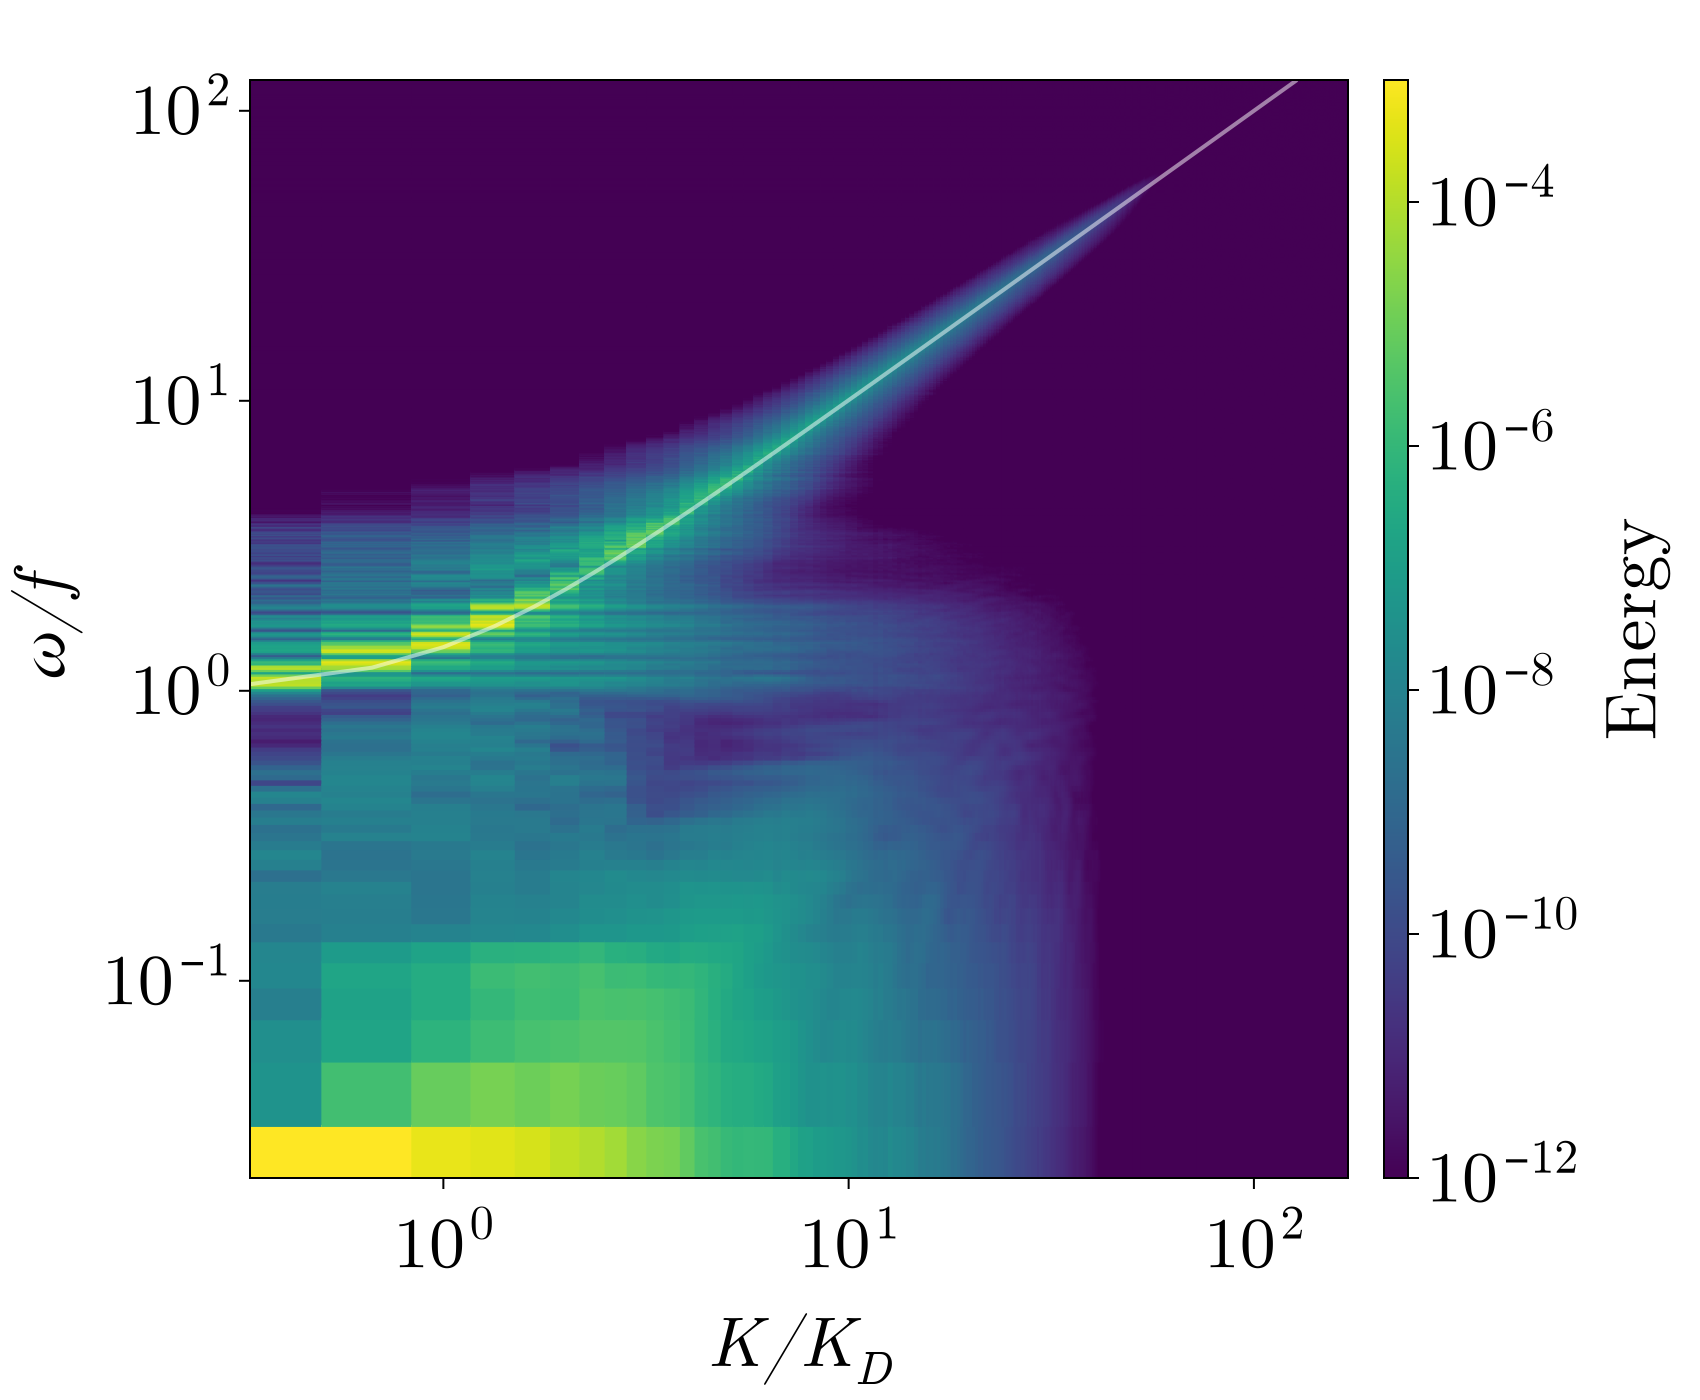

In [79]:
Kd = 3
f0 = 3
file = jldopen(@sprintf("%s/%d/radial_data_k=%03d.jld2", msw_fourier_directory, 1, 1))
ω_size = size(file["t"], 1)
t = file["t"]
Nω = length(t)
dt = 0.000205 * 40#t[2] - t[1] for some reason the time measurement is weird
ωs = fftshift(fftfreq(Nω, 1/dt) * 2π)
ωs[Npos:end]/f0
ωs = fftshift(fftfreq(Nω, 1/dt) * 2π)
close(file)
Nneg, Nzero, Npos = frequency_filters(Nω)
Npos = Npos[1]

fig = Figure(figure_padding = (0, 10, 0, 40), fonts = (; regular = "/home/nad9961/cmu-font/cmunrm.ttf", bold="/home/nad9961/cmu-font/cmunbx.ttf", math="/home/nad9961/cmu-font/cmunci.ttf"), size=(700, 700), fontsize=36)
ax = Axis(fig[1,1]; xscale=log10, yscale=log10, 
    xlabel=rich("K/K", subscript("D"), font=:math), ylabel=rich(rich("ω/f"; font=:math)),
    limits=((grid.kr[2]/Kd, grid.kr[end]/Kd), (ωs[Npos]/f0, ωs[end]/f0)), xticks=LogTicks(WilkinsonTicks(3; k_min=2)))

hm = heatmap!(ax, 
    grid.kr[2:end]/Kd, 
    ωs[Npos:end]/f0, 
    replace((rsw_g_Ch + rsw_w_Ch)[Npos:end,  2:grid.nkr]', 0.0=>1e-12), colorscale = log10, colorrange=(1e-12,1e-3))
lines!(ax, grid.kr[2:grid.nkr]/Kd, sqrt.(f0.^2 .+ grid.kr[2:grid.nkr].^2)/f0, color=:white, linewidth=2, alpha=0.5)
Colorbar(fig[1,2], hm, ticks=LogTicks(WilkinsonTicks(5; k_min=5)), label="Energy")
colsize!(fig.layout, 1, Aspect(1, 1.0))
resize_to_layout!(fig)

save("images/rsw_energy.png", fig)
fig

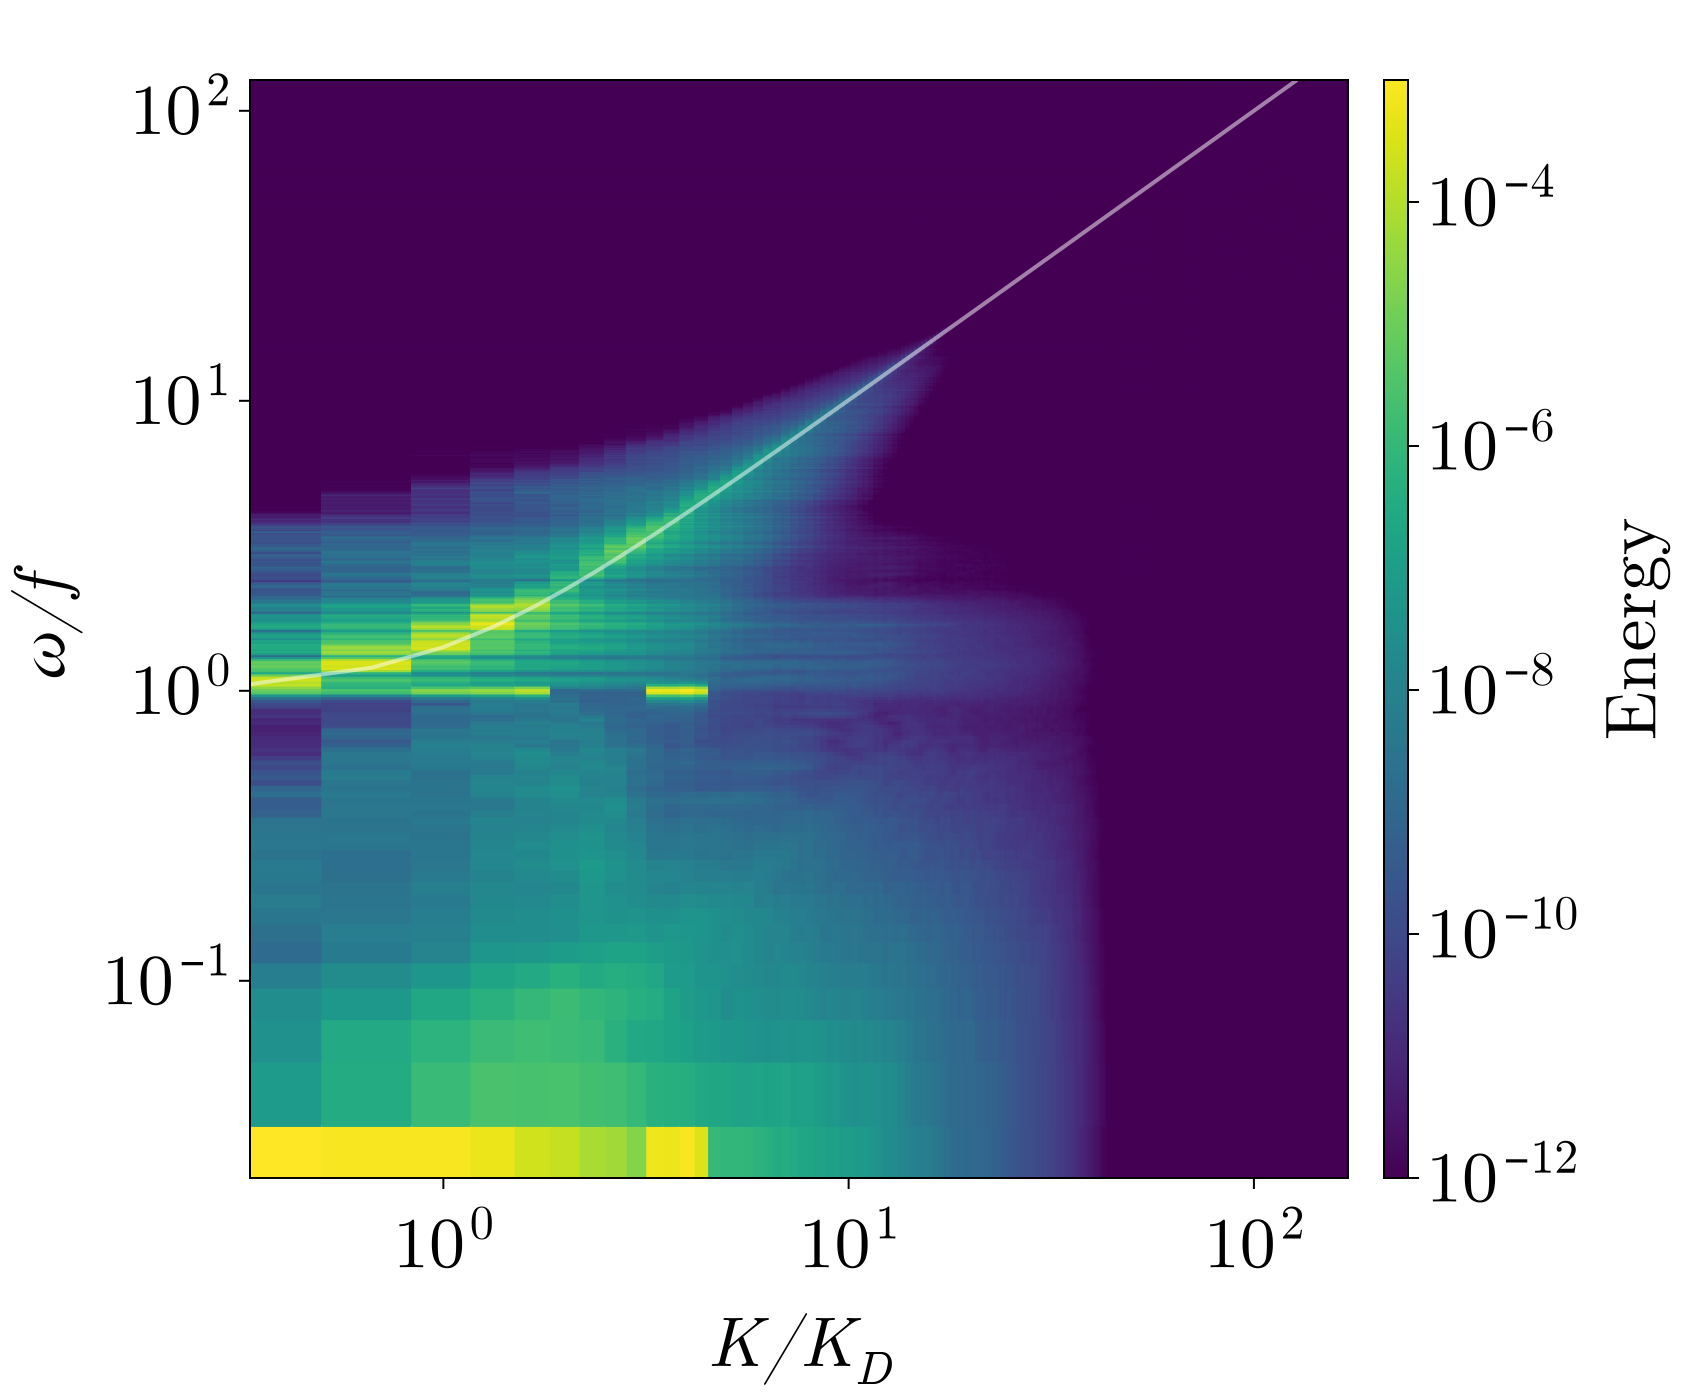

In [80]:
Kd = 3
f0 = 3
file = jldopen(@sprintf("%s/%d/radial_data_k=%03d.jld2", msw_fourier_directory, 1, 1))
ω_size = size(file["t"], 1)
t = file["t"]
Nω = length(t)
dt = 0.000205 * 40#t[2] - t[1] for some reason the time measurement is weird
ωs = fftshift(fftfreq(Nω, 1/dt) * 2π)
ωs[Npos:end]/f0
ωs = fftshift(fftfreq(Nω, 1/dt) * 2π)
close(file)
Nneg, Nzero, Npos = frequency_filters(Nω)
Npos = Npos[1]

fig = Figure(figure_padding = (0, 10, 0, 40), fonts = (; regular = "/home/nad9961/cmu-font/cmunrm.ttf", bold="/home/nad9961/cmu-font/cmunbx.ttf", math="/home/nad9961/cmu-font/cmunci.ttf"), size=(700, 700), fontsize=36)
ax = Axis(fig[1,1]; xscale=log10, yscale=log10, 
    xlabel=rich("K/K", subscript("D"), font=:math), ylabel=rich(rich("ω/f"; font=:math)),
    limits=((grid.kr[2]/Kd, grid.kr[end]/Kd), (ωs[Npos]/f0, ωs[end]/f0)), xticks=LogTicks(WilkinsonTicks(3; k_min=2)))

hm = heatmap!(ax, 
    grid.kr[2:end]/Kd, 
    ωs[Npos:end]/f0, 
    replace((msw_g_Ch + msw_w_Ch)[Npos:end,  2:grid.nkr]', 0.0=>1e-12), colorscale = log10, colorrange=(1e-12,1e-3))
lines!(ax, grid.kr[2:grid.nkr]/Kd, sqrt.(f0.^2 .+ grid.kr[2:grid.nkr].^2)/f0, color=:white, linewidth=2, alpha=0.5)
Colorbar(fig[1,2], hm, ticks=LogTicks(WilkinsonTicks(5; k_min=5)), label="Energy")
colsize!(fig.layout, 1, Aspect(1, 1.0))
resize_to_layout!(fig)

save("images/msw_energy.png", fig)
fig

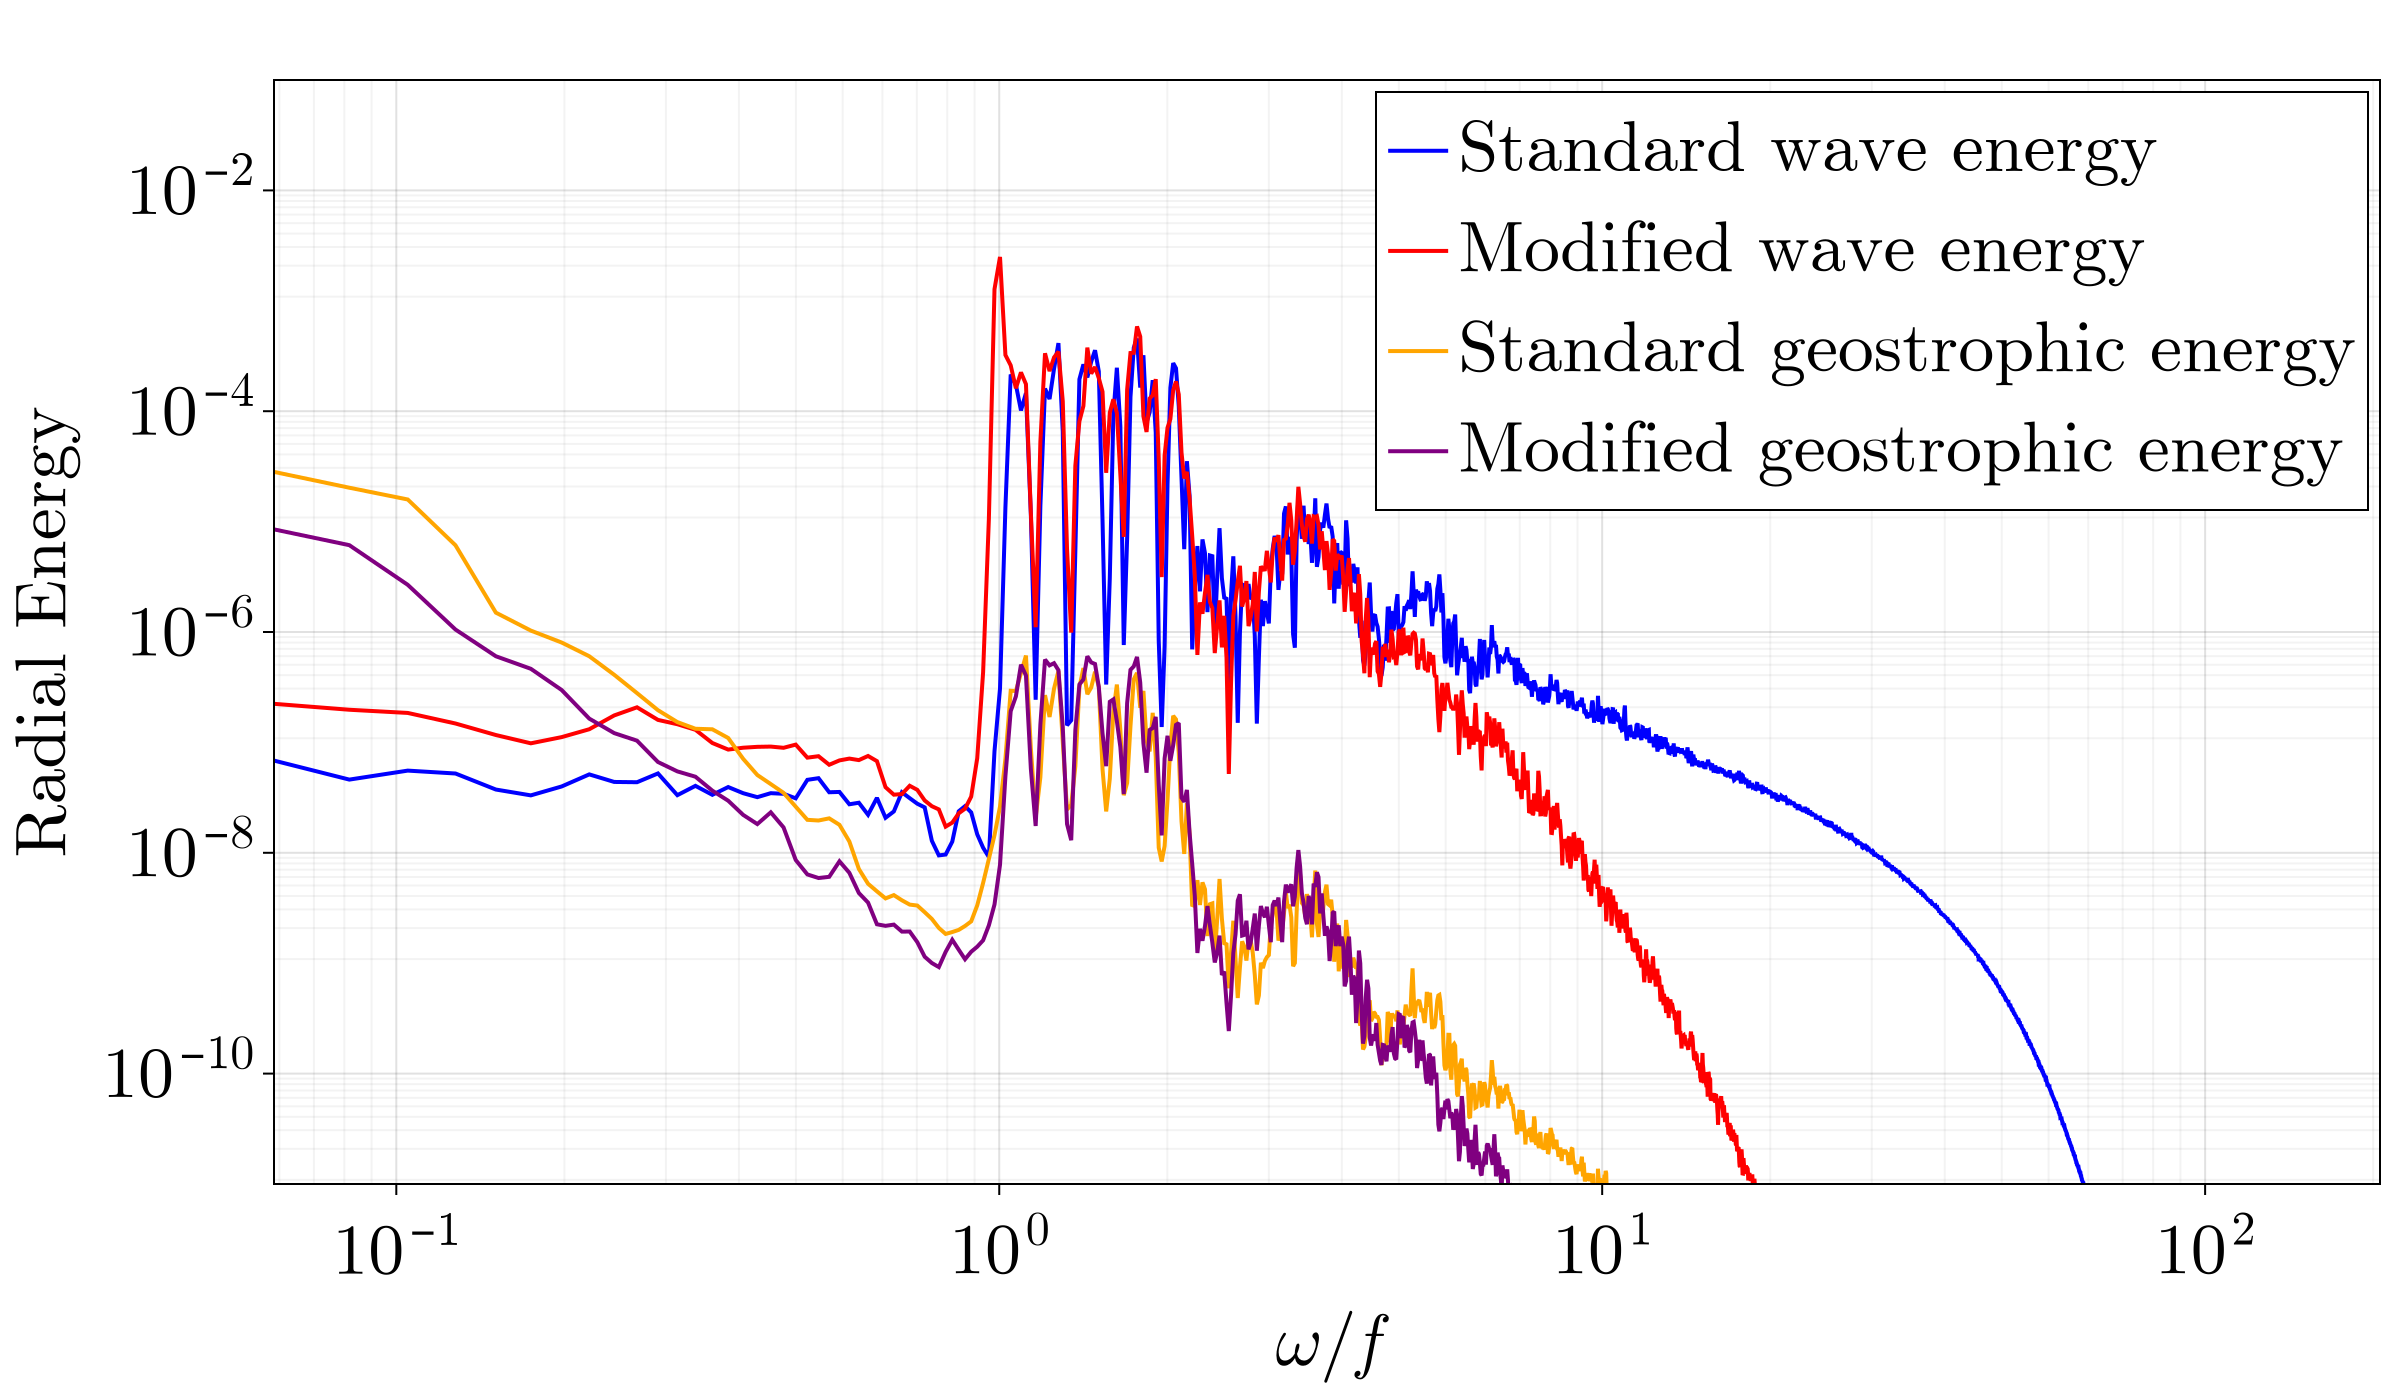

In [136]:
fig = Figure(figure_padding=(0, 10, 10, 40); fonts = (; regular = "/home/nad9961/cmu-font/cmunrm.ttf", bold="/home/nad9961/cmu-font/cmunbx.ttf", math="/home/nad9961/cmu-font/cmunci.ttf"), size=(1200, 700), fontsize=36)

ax_opts = (; xscale=log10, yscale=log10, 
        ylabel = "Radial Energy",
        xlabel=L"$\omega/f$", xticks=LogTicks(WilkinsonTicks(3; k_min=3)), 
        yticks=LogTicks(WilkinsonTicks(7; k_min=4)),
        xminorticks=IntervalsBetween(10),
        xminorgridvisible=true,
        yminorticks=IntervalsBetween(10),
        yminorgridvisible=true,
        limits=((ωs[Npos], ωs[end-3000]), (1e-11, 1e-1)))

ax = Axis(fig[1,1]; xscale=log10, yscale=log10, ax_opts...)

lines!(ax, ωs[Npos:end]/f0, rsw_w_Cω[Npos:end]; linewidth=2, color=:blue, label="Standard wave energy")
lines!(ax, ωs[Npos:end]/f0, msw_w_Cω[Npos:end]; linewidth=2, color=:red, label="Modified wave energy")
lines!(ax, ωs[Npos:end]/f0, rsw_g_Cω[Npos:end]; linewidth=2, color=:orange, label="Standard geostrophic energy")
lines!(ax, ωs[Npos:end]/f0, msw_g_Cω[Npos:end]; linewidth=2, color=:purple, label="Modified geostrophic energy")

#lines!(ax, ωs[Npos:end]/f0, 7e-4*ωs[Npos:end].^(-2)/f0, color="black", linestyle=:solid, linewidth=1)
#lines!(ax, ωs[Npos:end]/f0, 1e-2*ωs[Npos:end].^(-3)/f0, color="black", linestyle=:solid, linewidth=1)


#text!(ax, ωs[Npos:end][ρ10_idx]/f0, power_2[ρ10_idx], text=L"K^{-2}")
axislegend(ax, position=:rt, fontsize=24, patchsize=(30, 30))
resize_to_layout!(fig)


save("images/msw_rsw_comparison_freq.eps", fig)

fig

In [98]:
ρ10_idx

6592

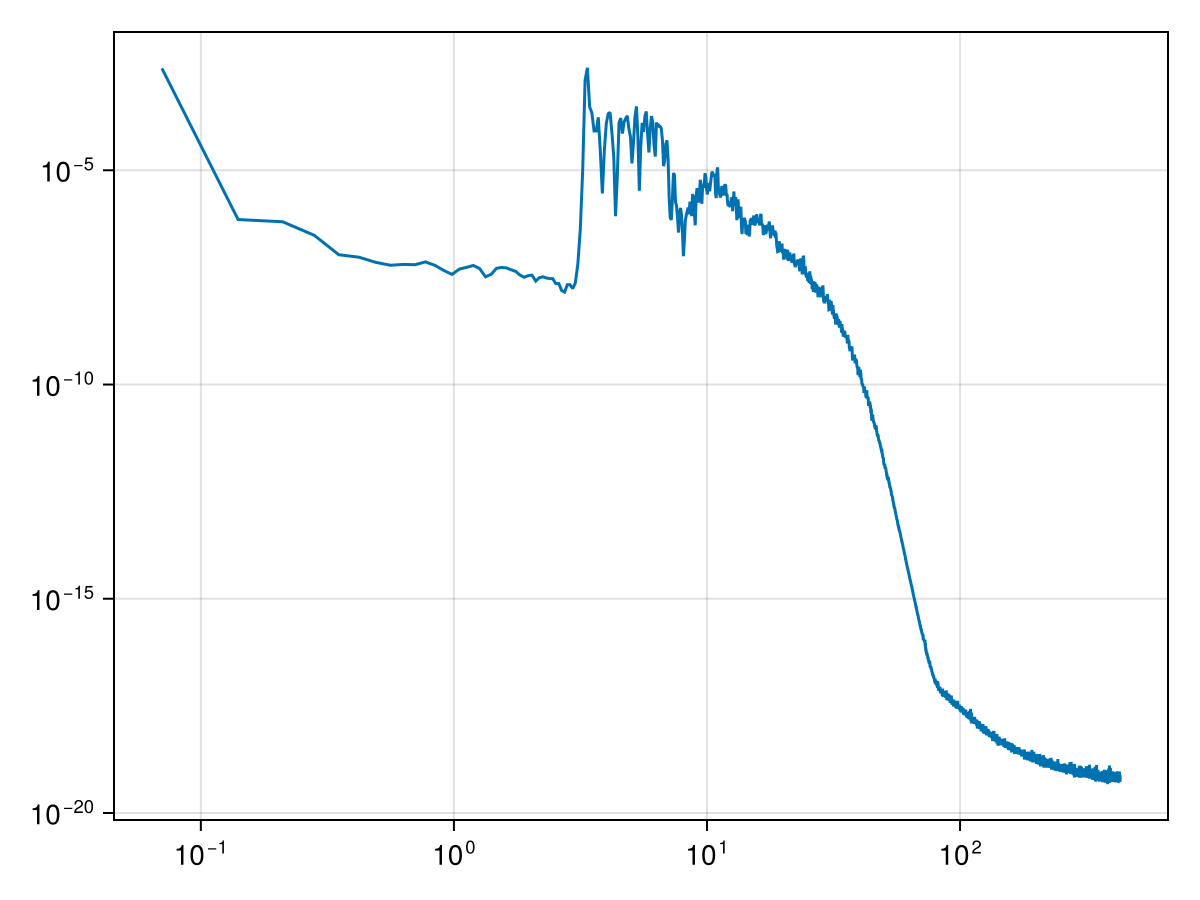

In [54]:
fig2 = Figure()
ax = Axis(fig2[1,1]; xscale=log10, yscale=log10)
lines!(ax, ωs[Npos:end], Cω[Npos:end])

fig2

In [24]:
Ch[Npos:end, :]

501×1026 Matrix{Float64}:
 1.42829e-18  2.10181e-18  1.99462e-18  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 1.50665e-18  2.34402e-18  2.578e-18       0.0  0.0  0.0  0.0  0.0  0.0  0.0
 1.58368e-18  3.54295e-18  2.33838e-18     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 1.26975e-18  4.08308e-18  1.96709e-18     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 1.39267e-18  4.60511e-18  2.57395e-18     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 1.1173e-18   2.90688e-18  5.05324e-18  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 2.56977e-18  3.30776e-18  6.05429e-18     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 1.02161e-18  4.66054e-18  4.51988e-18     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 1.69507e-18  5.25036e-18  4.79745e-18     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 1.97454e-18  3.11984e-18  4.21315e-18     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 6.62766e-18  4.07191e-18  4.09545e-18  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 9.1879e-18   2.7578e-18   2.31198e-18     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 3.76825e-18  3.31364e-18  2.22141e-18     0.0  0.

In [73]:
dt

0.008199999999999999

In [74]:
t[9]-t[8]

0.009765625

In [43]:
function gaussian_window(N, σ)
    n = -N:N
    window = exp.(-n.^2/(2*σ^2))
    return window / sum(window)
end

function apply_gaussian_window(data, window, Ndata, N)
    result = zeros(Ndata - 2*N, size(data, 2))
    for i=(N+1):(Ndata-N)
        result[i - N,:] = sum(data[i-N:i+N,:].*window, dims=1)
    end
    return result
end

function get_new_axis(axis, window, Ndata, N)
    result = zeros(Ndata - 2*N)
    for i=(N+1):(Ndata-N)
        result[i - N] = sum(axis[i-N:i+N].*window)
    end
    return result
end

#window = gaussian_window(10, 1.0)
#smoothed_data = apply_gaussian_window(Ch, window, size(Ch, 1), 10)
#smooth_ω = get_new_axis(ωs, window, size(Ch, 1), 10)

12204-element Vector{Float64}:
 -428.23033012953397
 -428.16015144547464
 -428.0899727614154
 -428.01979407735615
 -427.94961539329694
 -427.8794367092377
 -427.80925802517845
 -427.7390793411191
 -427.6689006570599
 -427.5987219730007
 -427.5285432889415
 -427.45836460488215
 -427.3881859208229
    ⋮
  427.3881859208229
  427.45836460488215
  427.5285432889415
  427.5987219730007
  427.66890065705996
  427.7390793411192
  427.80925802517845
  427.87943670923767
  427.9496153932969
  428.0197940773562
  428.0899727614154
  428.16015144547464